In [1]:
from pathlib import Path
from os import environ

ROOT = Path(f"{Path.cwd().parents[1]}/outputs")
basedir = Path(f"{ROOT}/mixpoisson")
datadir = Path(f"{basedir}/data")
outputdir = Path(f"{basedir}/rlct")

if not outputdir.exists():
  outputdir.mkdir(exist_ok=True)
  print(f"Created {outputdir}!")

print(f"Using datadir={datadir}")
print(f"Using outputdir={outputdir}")

Using datadir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixpoisson/data
Using outputdir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixpoisson/rlct


In [2]:
import pandas as pd

dgps_file = f"{datadir}/dgp.csv"
dgps=pd.read_csv(dgps_file, index_col=0).reset_index()
dgps.head()

,dsid,m0,m1,w0,w1
0,regular,15,1,0.75,0.25
1,e-singular,10,5,0.75,0.25
2,singular1,10,5,1.00,0.00
3,singular2,5,5,0.75,0.25


In [3]:
from sklearn_extensions.mixpoisson import PoissonMixture
from scipy_extensions import mixpoisson


def find_truth_by_dsid(dsid: str):
  dgp = dgps.query(f"dsid=='{dsid}'")
  truth = dgp[["m0", "m1", "w0", "w1"]].iloc[0].tolist()
  return truth

def n_components_by_dsid(dsid: str):
  truth = find_truth_by_dsid(dsid)
  half_space = int(np.ceil(len(truth)/2))
  mus = truth[0: half_space]
  weights = truth[half_space: len(truth)]
  return mixpoisson.n_components(mus=mus, weights=weights)

def rlct_by_dsid(dsid: str, k: int):
  n_components0 = n_components_by_dsid(dsid)
  return mixpoisson.rlct(d=1, r=n_components0, k=k)

In [15]:
import pandas as pd
import json
from pathlib import Path

rlcthat_filename = "toru_watanabe.csv"
rlcthat_file = Path(f"{outputdir}/{rlcthat_filename}")

rlcthat_df = pd.read_csv(rlcthat_file)
rlcthat_df.head()

,rlct,hypers,mean_divergences,total_divergences,max_divergences,divergences_per_chain,chain_tree_depth,dsid,regime,k,n,trial,chains,draws,tune,name,duration
0,1.340342,"c=1,d=1",0.0,0,0,"[0, 0]",5,regular,50,2,50,0,1,2000,4000,watanabe,30.435261
1,1.298237,c=1,0.0,0,0,[0],5,regular,50,2,50,0,1,2000,4000,toru,17.408283
2,1.345941,"c=1,d=1",0.0,0,0,"[0, 0]",7,e-singular,50,2,50,0,1,2000,4000,watanabe,30.736952
3,1.256258,c=1,0.0,0,0,[0],8,e-singular,50,2,50,0,1,2000,4000,toru,18.140732
4,0.960536,"c=1,d=1",0.0,0,0,"[0, 0]",9,singular1,50,2,50,0,1,2000,4000,watanabe,34.333542


In [18]:
# name vs dsid
print(pd.crosstab(rlcthat_df['dsid'], rlcthat_df['name']))

# name vs k
print(pd.crosstab(rlcthat_df['k'], rlcthat_df['name']))

# name vs n
print(pd.crosstab(rlcthat_df['n'], rlcthat_df['name']))

name        toru  watanabe
dsid                      
e-singular   294       294
regular      294       294
singular1    294       294
singular2    294       294
name  toru  watanabe
k                   
2      392       392
3      392       392
5      392       392
name  toru  watanabe
n                   
50     396       396
250    396       396
5000   384       384


In [20]:
rlcthat_df = rlcthat_df[rlcthat_df['dsid'] != 'singular2']

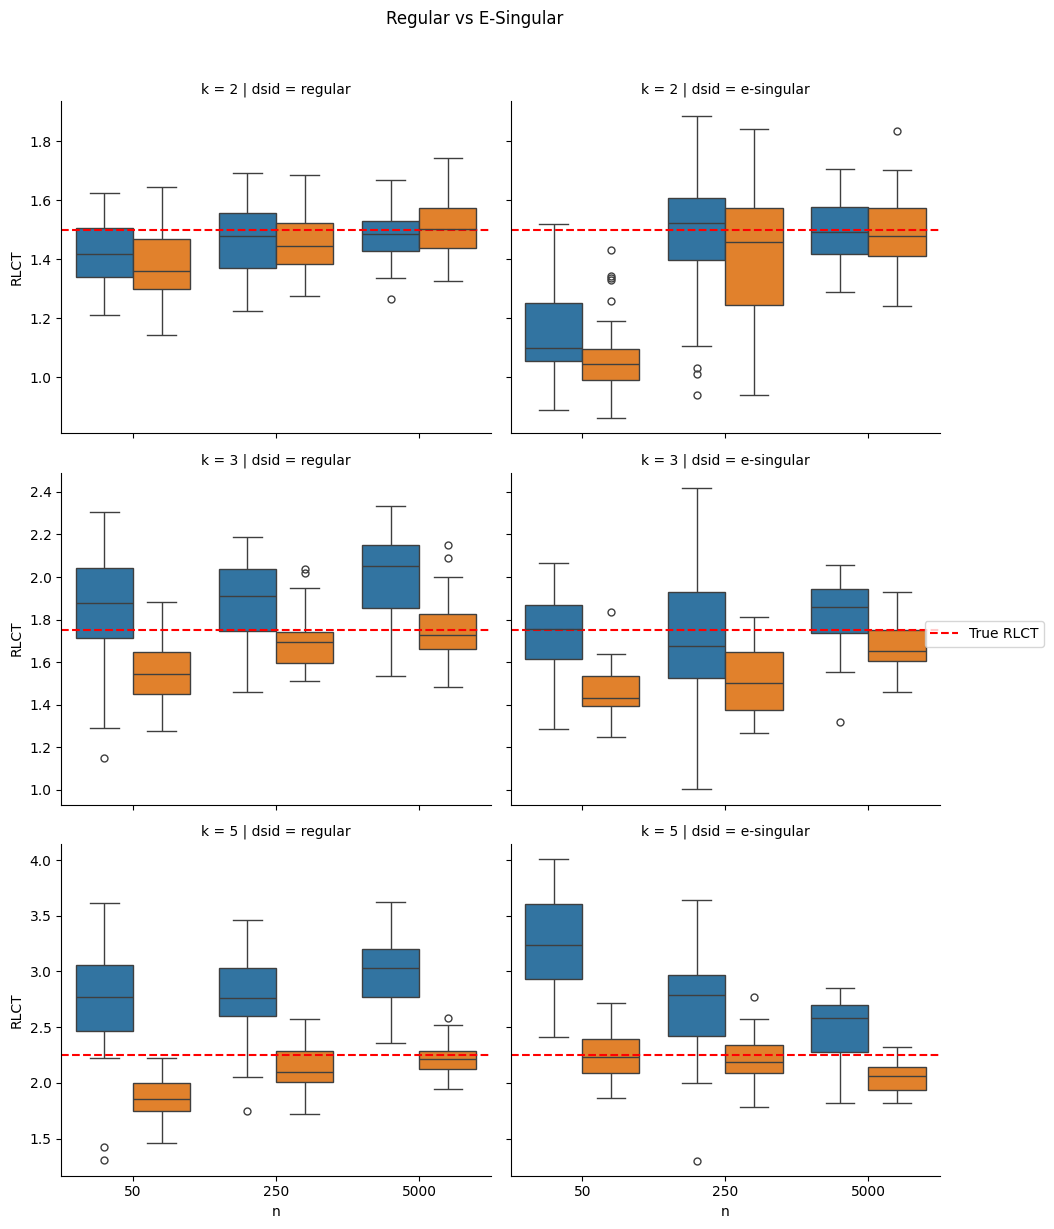

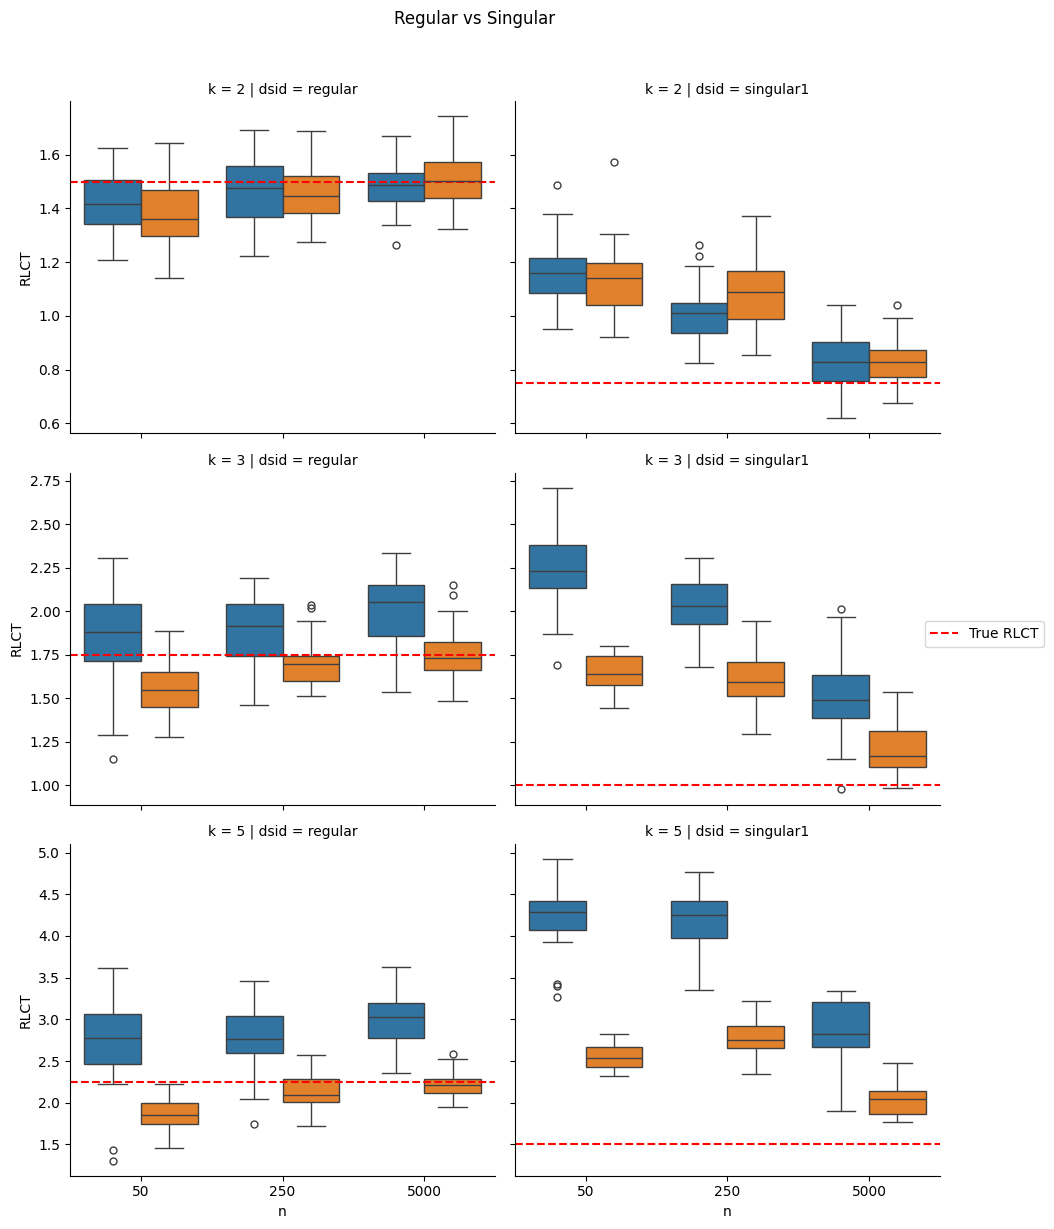

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Plot 1: regular and e-singular
plot_df1 = rlcthat_df[rlcthat_df['dsid'].isin(['regular', 'e-singular'])]

g1 = sns.catplot(
    data=plot_df1,
    x='n',
    y='rlct',
    hue='name',
    col='dsid',
    row='k',
    kind='box',
    height=4,
    aspect=1.2,
    legend=False,
    sharey='row'
)

for ax in g1.axes.flat:
    title = ax.get_title()
    parts = title.split(' | ')
    k = int(parts[0].split(' = ')[1])
    dsid = parts[1].split(' = ')[1]
    true_rlct = rlct_by_dsid(dsid, k)
    ax.axhline(y=true_rlct, color='red', linestyle='--', linewidth=1.5)

handles, labels = g1.axes.flat[0].get_legend_handles_labels()
handles.append(Line2D([0], [0], color='red', linestyle='--', linewidth=1.5))
labels.append('True RLCT')
g1.fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.1, 0.5))
g1.set_axis_labels("n", "RLCT")
g1.fig.suptitle("Regular vs E-Singular", y=1.02)
plt.tight_layout()
plt.show()

# Plot 2: regular, singular1, singular2
plot_df2 = rlcthat_df[rlcthat_df['dsid'].isin(['regular', 'singular1', 'singular2'])]

g2 = sns.catplot(
    data=plot_df2,
    x='n',
    y='rlct',
    hue='name',
    col='dsid',
    row='k',
    kind='box',
    height=4,
    aspect=1.2,
    legend=False,
    sharey='row'
)

for ax in g2.axes.flat:
    title = ax.get_title()
    parts = title.split(' | ')
    k = int(parts[0].split(' = ')[1])
    dsid = parts[1].split(' = ')[1]
    true_rlct = rlct_by_dsid(dsid, k)
    ax.axhline(y=true_rlct, color='red', linestyle='--', linewidth=1.5)

handles, labels = g2.axes.flat[0].get_legend_handles_labels()
handles.append(Line2D([0], [0], color='red', linestyle='--', linewidth=1.5))
labels.append('True RLCT')
g2.fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.1, 0.5))
g2.set_axis_labels("n", "RLCT")
g2.fig.suptitle("Regular vs Singular", y=1.02)
plt.tight_layout()
plt.show()

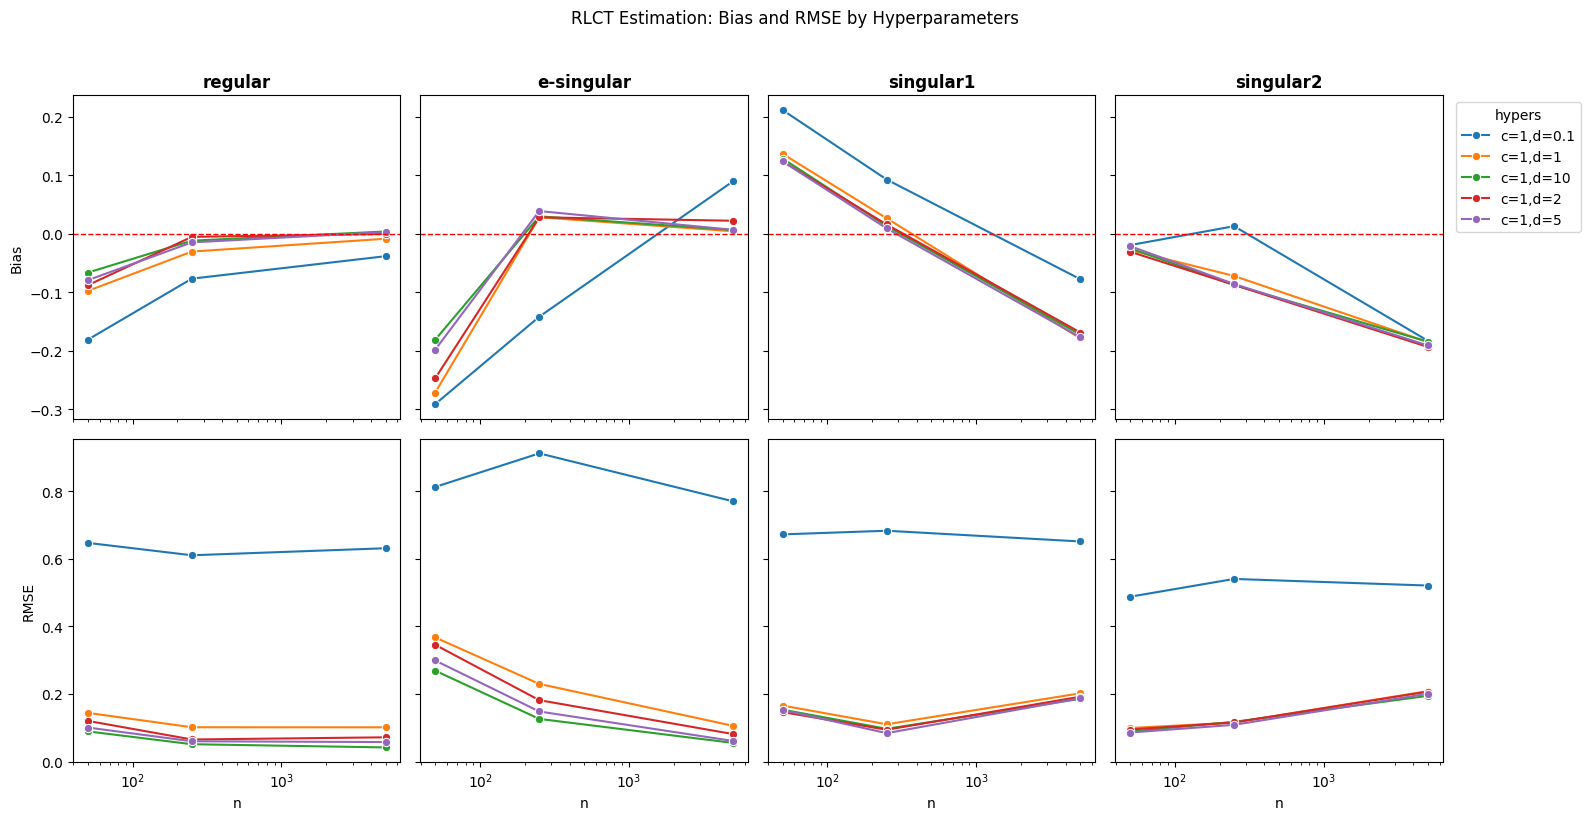

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compute summary statistics
summary = rlct_estimates_df.groupby(['dsid', 'n', 'hypers']).agg(
    mean_rlct=('rlct', 'mean'),
    std_rlct=('rlct', 'std'),
    median_rlct=('rlct', 'median')
).reset_index()

# Add true RLCT and compute bias/rmse
summary['true_rlct'] = summary['dsid'].apply(rlct_by_dsid)
summary['bias'] = summary['mean_rlct'] - summary['true_rlct']
summary['rmse'] = np.sqrt(summary['bias']**2 + summary['std_rlct']**2)

dsids = ['regular', 'e-singular', 'singular1', 'singular2']

fig, axes = plt.subplots(2, len(dsids), figsize=(4*len(dsids), 8), sharex=True, sharey='row')

for j, dsid in enumerate(dsids):
    data = summary[summary['dsid'] == dsid]
    
    # Top row: Bias
    ax = axes[0, j]
    sns.lineplot(
        data=data,
        x='n',
        y='bias',
        hue='hypers',
        marker='o',
        ax=ax
    )
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xscale('log')
    ax.set_title(dsid, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Bias' if j == 0 else '')
    
    if j < len(dsids) - 1:
        ax.get_legend().remove()
    else:
        ax.legend(title='hypers', bbox_to_anchor=(1.02, 1), loc='upper left')
    
    # Bottom row: RMSE
    ax = axes[1, j]
    sns.lineplot(
        data=data,
        x='n',
        y='rmse',
        hue='hypers',
        marker='o',
        ax=ax
    )
    ax.set_xscale('log')
    ax.set_xlabel('n')
    ax.set_ylabel('RMSE' if j == 0 else '')
    ax.get_legend().remove()

plt.suptitle('RLCT Estimation: Bias and RMSE by Hyperparameters', y=1.02)
plt.tight_layout()
plt.show()

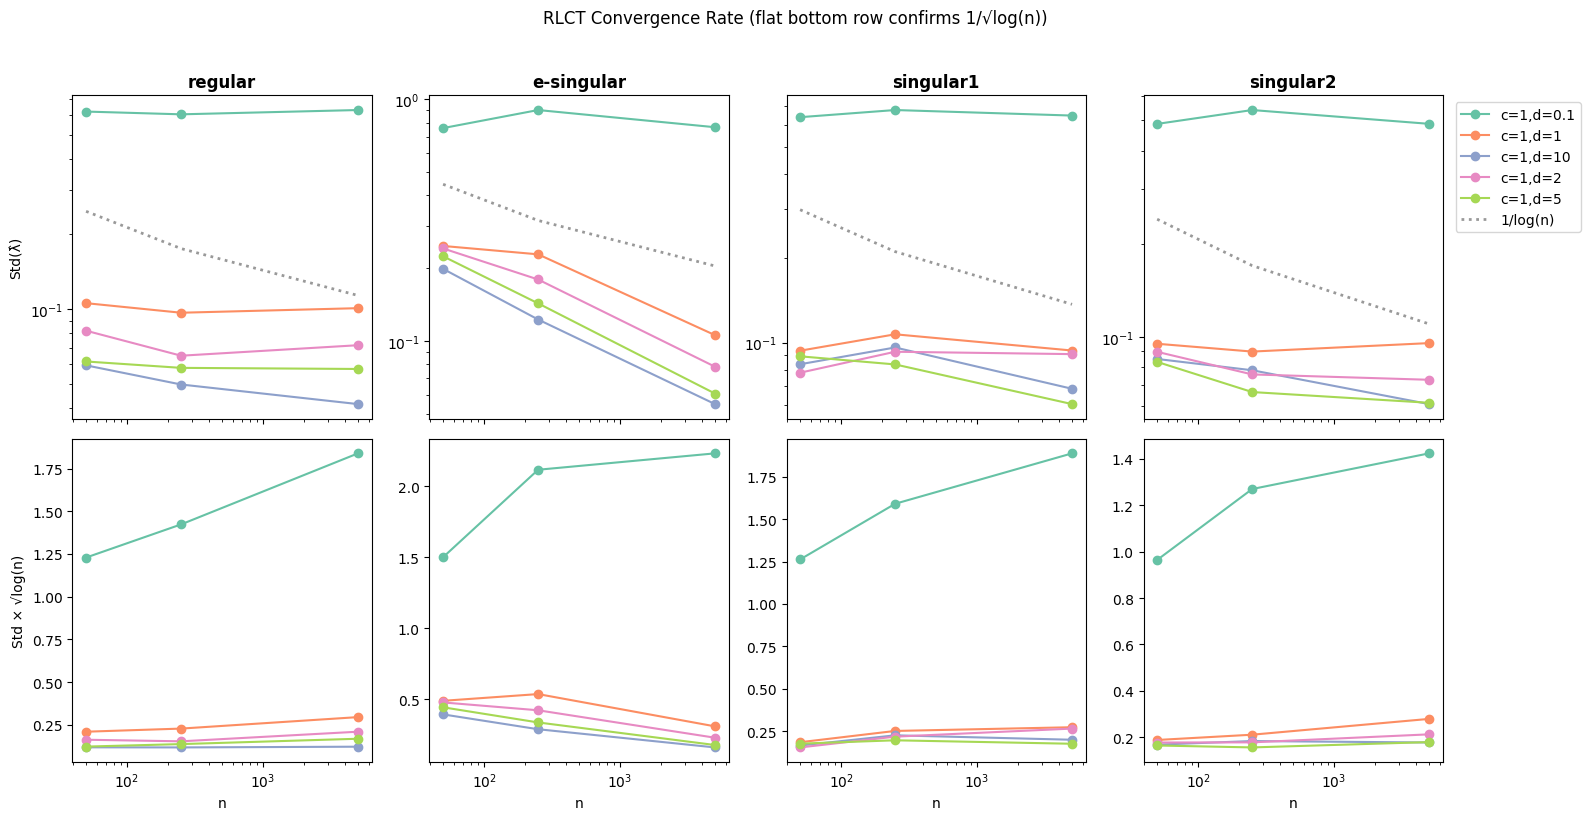

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compute summary statistics
summary = rlct_estimates_df.groupby(['dsid', 'n', 'hypers']).agg(
    mean_rlct=('rlct', 'mean'),
    std_rlct=('rlct', 'std')
).reset_index()

summary['true_rlct'] = summary['dsid'].apply(rlct_by_dsid)
summary['std_normalized'] = summary['std_rlct'] * np.sqrt(np.log(summary['n']))

dsids = ['regular', 'e-singular', 'singular1', 'singular2']
hypers_list = summary['hypers'].unique()
palette = sns.color_palette('Set2', len(hypers_list))
hyper_colors = dict(zip(hypers_list, palette))

n_range = np.array(sorted(summary['n'].unique()))

fig, axes = plt.subplots(2, len(dsids), figsize=(4*len(dsids), 8), sharex=True)

for j, dsid in enumerate(dsids):
    data = summary[summary['dsid'] == dsid]
    
    # Top row: Std with reference line
    ax = axes[0, j]
    
    for hyper in hypers_list:
        hdata = data[data['hypers'] == hyper].sort_values('n')
        ax.plot(hdata['n'], hdata['std_rlct'], 'o-', 
                label=hyper, color=hyper_colors[hyper])
    
    # Reference line anchored at midpoint
    mid_idx = len(n_range) // 2
    ref_n = n_range[mid_idx]
    ref_std = data.groupby('n')['std_rlct'].mean().iloc[mid_idx]
    
    ax.plot(n_range, ref_std * (np.log(ref_n) / np.log(n_range)), 
            'k:', alpha=0.4, linewidth=2, label='1/log(n)')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('')
    ax.set_ylabel('Std(λ̂)' if j == 0 else '')
    ax.set_title(dsid, fontweight='bold')
    
    if j == len(dsids) - 1:
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    
    # Bottom row: Std × √log(n)
    ax = axes[1, j]
    
    for hyper in hypers_list:
        hdata = data[data['hypers'] == hyper].sort_values('n')
        ax.plot(hdata['n'], hdata['std_normalized'], 'o-', 
                label=hyper, color=hyper_colors[hyper])
    
    ax.set_xscale('log')
    ax.set_xlabel('n')
    ax.set_ylabel('Std × √log(n)' if j == 0 else '')
    ax.get_legend().remove() if ax.get_legend() else None

plt.suptitle('RLCT Convergence Rate (flat bottom row confirms 1/√log(n))', y=1.02)
plt.tight_layout()
plt.show()